In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy import stats
from openpyxl import Workbook
from openpyxl.styles import (
    Font, PatternFill, Alignment, Border, Side, numbers
)
from openpyxl.utils import get_column_letter
from openpyxl.worksheet.table import Table, TableStyleInfo
import datetime

STOCKS = ["XOM", "NFLX", "PLTR", "DAL", "KO"]

CLEANING_CONFIG = {
    "zscore_threshold": 3.5,
    "volume_zscore_threshold": 4.0,
    "iqr_multiplier": 1.5,
    "min_rows": 5,
    "max_gap_fill": 3,
    "price_zero_threshold": 0.01,
}

# ── Colors ───────────────────────────────────────────────────────────────────
CLR = {
    "header_bg":   "1A1A2E",   # deep navy
    "header_fg":   "E8F4FD",   # near-white
    "subheader":   "16213E",   # dark blue
    "accent":      "0F3460",
    "row_alt":     "EEF4FB",   # light blue-grey
    "row_white":   "FFFFFF",
    "pos":         "D4EDDA",   # green tint
    "neg":         "F8D7DA",   # red tint
    "summary_hdr": "0F3460",
    "tab_blue":    "2E86AB",
    "tab_green":   "27AE60",
    "tab_orange":  "E67E22",
    "tab_red":     "E74C3C",
    "tab_purple":  "8E44AD",
}

TICKER_COLORS = ["2E86AB", "27AE60", "E67E22", "E74C3C", "8E44AD"]

thin = Side(style="thin", color="CCCCCC")
med  = Side(style="medium", color="888888")
BORDER_THIN  = Border(left=thin, right=thin, top=thin, bottom=thin)
BORDER_BOTTOM= Border(bottom=Side(style="medium", color="0F3460"))


def _fill(hex_color):
    return PatternFill("solid", fgColor=hex_color)

def _font(bold=False, color="000000", size=10, italic=False):
    return Font(name="Arial", bold=bold, color=color, size=size, italic=italic)

def _align(h="left", v="center", wrap=False):
    return Alignment(horizontal=h, vertical=v, wrap_text=wrap)

def _set_col_width(ws, col, width):
    ws.column_dimensions[get_column_letter(col)].width = width


# ─────────────────────────────────────────────
# DATA FETCHING
# ─────────────────────────────────────────────
def get_stock_data(ticker, period="6mo", interval="1h"):
    try:
        df = yf.download(ticker, period=period, interval=interval,
                         auto_adjust=True, progress=False)
        if df.empty:
            return None
        df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
        df = df[["Open", "High", "Low", "Close", "Volume"]]
        return df
    except Exception as e:
        print(f"Error fetching {ticker}: {e}")
        return None

def get_multiple_stocks(tickers=STOCKS, period="max", interval="1d"):
    data = {}
    for ticker in tickers:
        df = get_stock_data(ticker, period, interval)
        if df is not None:
            data[ticker] = df
            print(f"  ✅ {ticker}: {len(df)} rows")
        else:
            print(f"  ❌ {ticker}: failed")
    return data


# ─────────────────────────────────────────────
# AUDIT
# ─────────────────────────────────────────────
def audit_missing(df, ticker):
    total = len(df)
    missing_counts = df.isnull().sum()
    missing_pct = (missing_counts / total * 100).round(2)
    dup_count = df.index.duplicated().sum()
    if len(df) > 1:
        deltas = pd.Series(df.index).diff().dropna()
        expected = deltas.mode()[0]
        gap_count = int((deltas > expected * 1.5).sum())
    else:
        gap_count = 0
    return {
        "ticker": ticker, "total_rows": total,
        "duplicate_timestamps": int(dup_count),
        "time_gaps": gap_count,
        "missing": missing_counts[missing_counts > 0].to_dict(),
        "missing_pct": missing_pct[missing_pct > 0].to_dict(),
    }


# ─────────────────────────────────────────────
# ANOMALY DETECTION
# ─────────────────────────────────────────────
def detect_anomalies(df, cfg=CLEANING_CONFIG):
    df = df.copy()
    price_cols = ["Open", "High", "Low", "Close"]
    df["flag_price_ohlc"] = (
        (df["High"] < df["Low"]) | (df["Close"] > df["High"]) |
        (df["Close"] < df["Low"]) | (df["Open"] > df["High"]) |
        (df["Open"] < df["Low"])
    )
    df["flag_price_zero"] = (df[price_cols] < cfg["price_zero_threshold"]).any(axis=1)
    z_close = np.abs(stats.zscore(df["Close"].dropna()))
    z_series = pd.Series(z_close, index=df["Close"].dropna().index)
    df["flag_price_zscore"] = z_series.reindex(df.index).fillna(False) > cfg["zscore_threshold"]
    spread = (df["High"] - df["Low"]) / df["Close"]
    df["flag_price_spread"] = spread > spread.median() * 10
    non_zero_vol = df["Volume"][df["Volume"] > 0]
    if len(non_zero_vol) > 3:
        z_vol = np.abs(stats.zscore(non_zero_vol))
        z_vol_s = pd.Series(z_vol, index=non_zero_vol.index)
        df["flag_volume_zscore"] = (
            z_vol_s.reindex(df.index).fillna(0) > cfg["volume_zscore_threshold"]
        )
    else:
        df["flag_volume_zscore"] = False
    q1, q3 = df["Volume"].quantile(0.25), df["Volume"].quantile(0.75)
    df["flag_volume_iqr"] = df["Volume"] > (q3 + cfg["iqr_multiplier"] * (q3 - q1))
    flag_cols = [c for c in df.columns if c.startswith("flag_")]
    df["is_anomaly"] = df[flag_cols].any(axis=1)
    return df


# ─────────────────────────────────────────────
# CLEANING
# ─────────────────────────────────────────────
def clean_stock_data(df, ticker, cfg=CLEANING_CONFIG):
    report = {"ticker": ticker, "steps": {}}
    original_len = len(df)
    dup_mask = df.index.duplicated(keep="first")
    df = df[~dup_mask]
    report["steps"]["duplicates_removed"] = int(dup_mask.sum())
    df = df.sort_index()
    ohlc_bad = (
        (df["High"] < df["Low"]) | (df["Close"] > df["High"]) |
        (df["Close"] < df["Low"]) | (df["Open"] > df["High"]) |
        (df["Open"] < df["Low"])
    )
    df = df[~ohlc_bad]
    report["steps"]["bad_ohlc_removed"] = int(ohlc_bad.sum())
    price_cols = ["Open", "High", "Low", "Close"]
    zero_price = (df[price_cols] < cfg["price_zero_threshold"]).any(axis=1)
    df = df[~zero_price]
    report["steps"]["zero_price_removed"] = int(zero_price.sum())
    before_na = df[price_cols].isnull().sum().sum()
    df[price_cols] = df[price_cols].ffill(limit=cfg["max_gap_fill"])
    report["steps"]["price_nans_filled"] = int(before_na - df[price_cols].isnull().sum().sum())
    still_na = df[price_cols].isnull().any(axis=1)
    df = df[~still_na]
    report["steps"]["remaining_nan_dropped"] = int(still_na.sum())
    vol_na = df["Volume"].isnull().sum()
    df["Volume"] = df["Volume"].fillna(0)
    report["steps"]["volume_nans_zeroed"] = int(vol_na)
    z = np.abs(stats.zscore(df["Close"]))
    outlier_mask = z > cfg["zscore_threshold"]
    if outlier_mask.sum() > 0:
        rolling_med = df["Close"].rolling(5, min_periods=1, center=True).median()
        df.loc[outlier_mask, "Close"] = rolling_med[outlier_mask]
    report["steps"]["price_outliers_winsorised"] = int(outlier_mask.sum())
    df["Volume"] = df["Volume"].astype(float)  # ensure float before capping
    q1, q3 = df["Volume"].quantile(0.25), df["Volume"].quantile(0.75)
    upper_fence = q3 + cfg["iqr_multiplier"] * (q3 - q1)
    vol_spike = df["Volume"] > upper_fence
    df.loc[vol_spike, "Volume"] = upper_fence
    report["steps"]["volume_spikes_capped"] = int(vol_spike.sum())
    if len(df) < cfg["min_rows"]:
        report["steps"]["DROPPED"] = f"Only {len(df)} rows — discarded"
        return None, report
    report["final_rows"] = len(df)
    report["rows_removed_total"] = original_len - len(df)
    return df, report


# ─────────────────────────────────────────────
# FEATURES
# ─────────────────────────────────────────────
def add_features(df):
    df = df.copy()
    df["returns"]       = df["Close"].pct_change()
    df["log_returns"]   = np.log(df["Close"] / df["Close"].shift(1))
    df["hl_spread"]     = df["High"] - df["Low"]
    df["typical_price"] = (df["High"] + df["Low"] + df["Close"]) / 3
    df["vwap"]          = (df["typical_price"] * df["Volume"]).cumsum() / df["Volume"].cumsum()
    df["vol_ma5"]       = df["Volume"].rolling(5, min_periods=1).mean()
    return df


# ─────────────────────────────────────────────
# EXCEL EXPORT
# ─────────────────────────────────────────────
def _write_cover(wb, clean_data, clean_reports, audits):
    ws = wb.active
    ws.title = "📊 Summary"
    ws.sheet_view.showGridLines = False

    # Title block
    ws.merge_cells("A1:J1")
    ws["A1"] = "STOCK DATA CLEANING REPORT"
    ws["A1"].font      = _font(bold=True, color=CLR["header_fg"], size=16)
    ws["A1"].fill      = _fill(CLR["header_bg"])
    ws["A1"].alignment = _align("center")
    ws.row_dimensions[1].height = 36

    ws.merge_cells("A2:J2")
    ws["A2"] = f"Generated: {datetime.datetime.now().strftime('%Y-%m-%d  %H:%M:%S')}   |   Tickers: {', '.join(clean_data.keys())}"
    ws["A2"].font      = _font(italic=True, color="AAAAAA", size=9)
    ws["A2"].fill      = _fill(CLR["subheader"])
    ws["A2"].alignment = _align("center")
    ws.row_dimensions[2].height = 18

    # Section header
    row = 4
    headers = ["Ticker", "Raw Rows", "Final Rows", "Removed", "Duplicates",
               "Bad OHLC", "Zero Price", "NaN Filled", "Outliers Fixed", "Vol Spikes Capped"]
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=row, column=c, value=h)
        cell.font      = _font(bold=True, color=CLR["header_fg"], size=10)
        cell.fill      = _fill(CLR["summary_hdr"])
        cell.alignment = _align("center")
        cell.border    = BORDER_THIN
    ws.row_dimensions[row].height = 22

    for i, (ticker, creport) in enumerate(clean_reports.items()):
        if "DROPPED" in creport.get("steps", {}):
            continue
        row += 1
        s = creport.get("steps", {})
        raw = audits[ticker]["total_rows"]
        final = creport.get("final_rows", raw)
        removed = creport.get("rows_removed_total", 0)
        vals = [
            ticker, raw, final, removed,
            s.get("duplicates_removed", 0),
            s.get("bad_ohlc_removed", 0),
            s.get("zero_price_removed", 0),
            s.get("price_nans_filled", 0),
            s.get("price_outliers_winsorised", 0),
            s.get("volume_spikes_capped", 0),
        ]
        bg = CLR["row_alt"] if i % 2 == 0 else CLR["row_white"]
        for c, v in enumerate(vals, 1):
            cell = ws.cell(row=row, column=c, value=v)
            cell.font      = _font(bold=(c == 1), color=("FFFFFF" if c == 1 else "222222"),
                                   size=10)
            cell.fill      = _fill(TICKER_COLORS[i % len(TICKER_COLORS)]) if c == 1 else _fill(bg)
            cell.alignment = _align("center" if c > 1 else "left")
            cell.border    = BORDER_THIN

    # Column widths
    widths = [10, 10, 10, 10, 12, 10, 12, 12, 15, 18]
    for col, w in enumerate(widths, 1):
        _set_col_width(ws, col, w)


def _write_ticker_sheet(wb, ticker, df, color):
    ws = wb.create_sheet(title=ticker)
    ws.sheet_view.showGridLines = False

    # Header row
    columns = list(df.columns)
    display_cols = ["Datetime"] + columns

    ws.merge_cells(f"A1:{get_column_letter(len(display_cols))}1")
    ws["A1"] = f"{ticker}  —  Cleaned & Enriched Data"
    ws["A1"].font      = _font(bold=True, color="FFFFFF", size=13)
    ws["A1"].fill      = _fill(color)
    ws["A1"].alignment = _align("center")
    ws.row_dimensions[1].height = 28

    # Column headers
    for c, col in enumerate(display_cols, 1):
        cell = ws.cell(row=2, column=c, value=col)
        cell.font      = _font(bold=True, color="FFFFFF", size=10)
        cell.fill      = _fill("1A1A2E")
        cell.alignment = _align("center")
        cell.border    = BORDER_THIN
    ws.row_dimensions[2].height = 20

    price_cols  = {"Open", "High", "Low", "Close", "typical_price", "vwap"}
    pct_cols    = {"returns", "log_returns"}
    int_cols    = {"Volume", "vol_ma5"}

    for row_i, (idx, row_data) in enumerate(df.iterrows(), start=3):
        bg = CLR["row_alt"] if row_i % 2 == 0 else CLR["row_white"]

        # Datetime
        cell = ws.cell(row=row_i, column=1, value=str(idx))
        cell.font      = _font(size=9, color="444444")
        cell.fill      = _fill(bg)
        cell.alignment = _align("center")
        cell.border    = BORDER_THIN

        for c_i, col in enumerate(columns, 2):
            val = row_data[col]
            if pd.isna(val):
                val = None
            cell = ws.cell(row=row_i, column=c_i, value=val)
            cell.font      = _font(size=9)
            cell.alignment = _align("right" if col not in ["returns"] else "right")
            cell.border    = BORDER_THIN

            if col in price_cols:
                cell.number_format = '#,##0.00'
                cell.fill = _fill(bg)
            elif col in pct_cols:
                cell.number_format = '0.000%'
                if val is not None:
                    cell.fill = _fill("D4EDDA") if val >= 0 else _fill("F8D7DA")
                else:
                    cell.fill = _fill(bg)
            elif col in int_cols:
                cell.number_format = '#,##0'
                cell.fill = _fill(bg)
            else:
                cell.number_format = '#,##0.000'
                cell.fill = _fill(bg)

    # Auto-fit column widths
    col_widths = {"Datetime": 20, "Open": 10, "High": 10, "Low": 10, "Close": 10,
                  "Volume": 14, "returns": 10, "log_returns": 12, "hl_spread": 11,
                  "typical_price": 14, "vwap": 12, "vol_ma5": 12}
    for c, col in enumerate(display_cols, 1):
        _set_col_width(ws, c, col_widths.get(col, 12))

    # Freeze panes below header
    ws.freeze_panes = "A3"


def export_to_excel(clean_data, clean_reports, audits, path="stock_cleaned.xlsx"):
    wb = Workbook()
    _write_cover(wb, clean_data, clean_reports, audits)

    for i, (ticker, df) in enumerate(clean_data.items()):
        color = TICKER_COLORS[i % len(TICKER_COLORS)]
        _write_ticker_sheet(wb, ticker, df, color)

    wb.save(path)
    print(f"\n  💾 Excel saved → {path}")
    return path


# ─────────────────────────────────────────────
# MASTER PIPELINE
# ─────────────────────────────────────────────
def run_pipeline(tickers=STOCKS, period="6mo", interval="1h",
                 output_path="stock_cleaned.xlsx"):
    # output_path: saves in current working directory by default.
    # Change to a full path if needed, e.g. '/content/stock_cleaned.xlsx' on Colab.
    print("── Fetching data ────────────────────────────────")
    raw_data = get_multiple_stocks(tickers, period, interval)

    audit_reports, clean_reports, clean_data, anomaly_data = {}, {}, {}, {}

    print("\n── Processing ───────────────────────────────────")
    for ticker, df in raw_data.items():
        audit_reports[ticker] = audit_missing(df, ticker)
        anomaly_data[ticker]  = detect_anomalies(df)
        df_clean, creport     = clean_stock_data(df, ticker)
        clean_reports[ticker] = creport
        if df_clean is not None:
            clean_data[ticker] = add_features(df_clean)
            print(f"  ✅ {ticker}: {creport['rows_removed_total']} rows removed → "
                  f"{creport['final_rows']} remain")
        else:
            print(f"  ⚠️  {ticker}: discarded")

    print(f"\n── Exporting ─────────────────────────────────────")
    export_to_excel(clean_data, clean_reports, audit_reports, path=output_path)

    print(f"\n{'═'*50}")
    print(f"  Done. {len(clean_data)}/{len(raw_data)} tickers exported.")
    print(f"{'═'*50}")
    return clean_data, audit_reports, clean_reports, anomaly_data


if __name__ == "__main__":
    run_pipeline(
    period="6mo",
    interval="1h"
)

── Fetching data ────────────────────────────────
  ✅ XOM: 853 rows
  ✅ NFLX: 853 rows
  ✅ PLTR: 853 rows
  ✅ DAL: 853 rows
  ✅ KO: 853 rows

── Processing ───────────────────────────────────
  ✅ XOM: 0 rows removed → 853 remain
  ✅ NFLX: 0 rows removed → 853 remain
  ✅ PLTR: 0 rows removed → 853 remain
  ✅ DAL: 0 rows removed → 853 remain
  ✅ KO: 0 rows removed → 853 remain

── Exporting ─────────────────────────────────────

  💾 Excel saved → stock_cleaned.xlsx

══════════════════════════════════════════════════
  Done. 5/5 tickers exported.
══════════════════════════════════════════════════


In [2]:
"""
stock_analysis.py
─────────────────
Four-part analysis module that runs on top of the cleaned pipeline output.

Usage:
    from stock_preprocessing import run_pipeline
    from stock_analysis import run_analysis

    clean_data, audits, clean_reports, anomaly_data = run_pipeline()
    run_analysis(clean_data)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── Global style ──────────────────────────────────────────────────────────────
PALETTE   = ["#2E86AB", "#27AE60", "#E67E22", "#E74C3C", "#8E44AD"]
BG        = "#0D1117"
PANEL     = "#161B22"
GRID_CLR  = "#21262D"
TEXT      = "#E6EDF3"
MUTED     = "#8B949E"
ACCENT    = "#58A6FF"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    PANEL,
    "axes.edgecolor":    GRID_CLR,
    "axes.labelcolor":   TEXT,
    "axes.titlecolor":   TEXT,
    "xtick.color":       MUTED,
    "ytick.color":       MUTED,
    "grid.color":        GRID_CLR,
    "grid.linewidth":    0.6,
    "text.color":        TEXT,
    "legend.facecolor":  PANEL,
    "legend.edgecolor":  GRID_CLR,
    "font.family":       "monospace",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

def _ticker_color(tickers):
    return {t: PALETTE[i % len(PALETTE)] for i, t in enumerate(tickers)}

def _save(fig, path):
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor=BG)
    plt.close(fig)
    print(f"  💾 Saved → {path}")


# ═════════════════════════════════════════════════════════════════════════════
# ANALYSIS 1 — INTRADAY PRICE & RETURNS
# ═════════════════════════════════════════════════════════════════════════════
def analysis_price_returns(clean_data, out="analysis_1_price_returns.png"):
    """
    Panel layout (per ticker row):
      Col 0: Normalised close price (rebased to 100)
      Col 1: 5-min returns bar chart (green/red)
      Col 2: Cumulative returns
    Bottom row: combined normalised price overlay (all tickers)
    """
    tickers = list(clean_data.keys())
    colors  = _ticker_color(tickers)
    n       = len(tickers)

    fig = plt.figure(figsize=(20, 4 * n + 4), facecolor=BG)
    fig.suptitle("ANALYSIS 1 — INTRADAY PRICE & RETURNS",
                 fontsize=15, fontweight="bold", color=TEXT, y=1.001)

    outer = gridspec.GridSpec(n + 1, 1, figure=fig, hspace=0.55)

    for i, ticker in enumerate(tickers):
        df    = clean_data[ticker].copy()
        clr   = colors[ticker]
        inner = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=outer[i],
                                                  wspace=0.35)

        # ── Normalised close ─────────────────────────────────────────────────
        ax0 = fig.add_subplot(inner[0])
        norm = df["Close"] / df["Close"].iloc[0] * 100
        ax0.plot(df.index, norm, color=clr, linewidth=1.5)
        ax0.fill_between(df.index, norm, 100,
                         where=(norm >= 100), alpha=0.15, color=clr)
        ax0.fill_between(df.index, norm, 100,
                         where=(norm < 100),  alpha=0.15, color="#E74C3C")
        ax0.axhline(100, color=MUTED, linewidth=0.8, linestyle="--")
        ax0.set_title(f"{ticker}  ·  Normalised Close", fontsize=9, color=clr)
        ax0.set_ylabel("Rebased to 100", fontsize=8)
        ax0.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax0.tick_params(labelsize=7)
        ax0.grid(True, alpha=0.4)



        # ── Cumulative returns ───────────────────────────────────────────────
        ax2 = fig.add_subplot(inner[2])
        cum = (1 + df["returns"].fillna(0)).cumprod() - 1
        final = cum.iloc[-1] * 100
        end_clr = clr if final >= 0 else "#E74C3C"
        ax2.plot(df.index, cum * 100, color=end_clr, linewidth=1.8)
        ax2.fill_between(df.index, cum * 100, 0, alpha=0.12, color=end_clr)
        ax2.axhline(0, color=MUTED, linewidth=0.8, linestyle="--")
        ax2.set_title(f"{ticker}  ·  Cumulative Return", fontsize=9, color=clr)
        ax2.set_ylabel("Cum. Return (%)", fontsize=8)
        ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax2.tick_params(labelsize=7)
        ax2.grid(True, alpha=0.4)

        # Annotate final cumulative return
        ax2.annotate(f"{final:+.2f}%",
                     xy=(df.index[-1], cum.iloc[-1] * 100),
                     xytext=(5, 0), textcoords="offset points",
                     fontsize=8, color=end_clr, fontweight="bold")

    # ── Bottom: all tickers normalised overlay ───────────────────────────────
    ax_all = fig.add_subplot(outer[n])
    for ticker in tickers:
        df   = clean_data[ticker]
        norm = df["Close"] / df["Close"].iloc[0] * 100
        ax_all.plot(df.index, norm, color=colors[ticker],
                    linewidth=1.6, label=ticker)
    ax_all.axhline(100, color=MUTED, linewidth=0.8, linestyle="--")
    ax_all.set_title("ALL TICKERS — Normalised Price Overlay", fontsize=10,
                     color=TEXT, fontweight="bold")
    ax_all.set_ylabel("Rebased to 100", fontsize=9)
    ax_all.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax_all.legend(fontsize=9, ncol=len(tickers))
    ax_all.grid(True, alpha=0.4)

    _save(fig, out)
    return _intraday_insights(clean_data, tickers, colors)


def _intraday_insights(clean_data, tickers, colors):
    rows = []
    for t in tickers:
        df  = clean_data[t]
        ret = df["returns"].dropna()
        cum = (1 + df["returns"].fillna(0)).cumprod().iloc[-1] - 1
        rows.append({
            "Ticker":        t,
            "Cum Return %":  round(cum * 100, 3),
            "Mean 5m Ret %": round(ret.mean() * 100, 4),
            "Max Up %":      round(ret.max() * 100, 3),
            "Max Down %":    round(ret.min() * 100, 3),
            "# Up Bars":     int((ret > 0).sum()),
            "# Down Bars":   int((ret < 0).sum()),
        })
    return pd.DataFrame(rows).set_index("Ticker")


# ═════════════════════════════════════════════════════════════════════════════
# ANALYSIS 2 — VOLATILITY
# ═════════════════════════════════════════════════════════════════════════════
def analysis_volatility(clean_data, window=10, out="analysis_2_volatility.png"):
    """
    Panels:
      Row 0: Rolling realised volatility (annualised) per ticker
      Row 1: Returns distribution (KDE) per ticker
      Row 2: Volatility heatmap (bar) — ranked comparison
      Row 3: Rolling vol overlay (all tickers)
    """
    tickers = list(clean_data.keys())
    colors  = _ticker_color(tickers)
    n       = len(tickers)
    BARS_PER_YEAR = 252 * 78   # 5-min bars in a trading year

    fig = plt.figure(figsize=(20, 18), facecolor=BG)
    fig.suptitle("ANALYSIS 2 — VOLATILITY", fontsize=15,
                 fontweight="bold", color=TEXT)

    gs = gridspec.GridSpec(3, n, figure=fig, hspace=0.55, wspace=0.35)

    vol_summary = {}

    # ── Row 0: Rolling vol per ticker ────────────────────────────────────────
    for i, ticker in enumerate(tickers):
        df  = clean_data[ticker]
        clr = colors[ticker]
        rolling_vol = (df["log_returns"]
                       .rolling(window, min_periods=2)
                       .std() * np.sqrt(BARS_PER_YEAR) * 100)
        vol_summary[ticker] = {
            "mean_vol":  rolling_vol.mean(),
            "max_vol":   rolling_vol.max(),
            "min_vol":   rolling_vol.min(),
        }

        ax = fig.add_subplot(gs[0, i])
        ax.plot(df.index, rolling_vol, color=clr, linewidth=1.4)
        ax.fill_between(df.index, rolling_vol, alpha=0.15, color=clr)
        ax.set_title(f"{ticker}  ·  Rolling Vol\n(ann., {window}-bar window)",
                     fontsize=9, color=clr)
        ax.set_ylabel("Ann. Vol (%)" if i == 0 else "", fontsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.4)
        # Mean line
        ax.axhline(rolling_vol.mean(), color=MUTED, linewidth=0.8,
                   linestyle="--", label=f"μ={rolling_vol.mean():.1f}%")
        ax.legend(fontsize=7)

    # ── Row 1: Returns KDE per ticker ────────────────────────────────────────
    for i, ticker in enumerate(tickers):
        df  = clean_data[ticker]
        clr = colors[ticker]
        ret = df["log_returns"].dropna()

        ax = fig.add_subplot(gs[1, i])
        ax.hist(ret * 100, bins=20, color=clr, alpha=0.35, density=True)
        kde_x = np.linspace(ret.min() * 100, ret.max() * 100, 200)
        kde   = stats.gaussian_kde(ret * 100)
        ax.plot(kde_x, kde(kde_x), color=clr, linewidth=1.8)
        ax.axvline(0, color=MUTED, linewidth=0.8, linestyle="--")
        ax.axvline(ret.mean() * 100, color=ACCENT, linewidth=1,
                   linestyle=":", label=f"μ={ret.mean()*100:.3f}%")
        skew = stats.skew(ret)
        kurt = stats.kurtosis(ret)
        ax.set_title(f"{ticker}  ·  Return Distribution\nskew={skew:.2f}  kurt={kurt:.2f}",
                     fontsize=9, color=clr)
        ax.set_xlabel("Log Return (%)", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.4)

    # ── Row 2: Vol comparison bar + rolling overlay ───────────────────────────
    gs2 = gridspec.GridSpec(1, 2, figure=fig, hspace=0.55, wspace=0.3,
                             top=0.28, bottom=0.04)

    # Bar chart: mean annualised vol
    ax_bar = fig.add_subplot(gs2[0, 0])
    sorted_tickers = sorted(vol_summary, key=lambda t: vol_summary[t]["mean_vol"], reverse=True)
    bar_vals  = [vol_summary[t]["mean_vol"] for t in sorted_tickers]
    bar_clrs  = [colors[t] for t in sorted_tickers]
    bars = ax_bar.barh(sorted_tickers, bar_vals, color=bar_clrs, alpha=0.85, height=0.55)
    for bar, val in zip(bars, bar_vals):
        ax_bar.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                    f"{val:.1f}%", va="center", fontsize=9, color=TEXT)
    ax_bar.set_xlabel("Mean Annualised Volatility (%)", fontsize=9)
    ax_bar.set_title("VOLATILITY RANKING", fontsize=10,
                     color=TEXT, fontweight="bold")
    ax_bar.tick_params(labelsize=9)
    ax_bar.grid(True, alpha=0.4, axis="x")
    ax_bar.invert_yaxis()

    # Overlay: all rolling vols
    ax_ov = fig.add_subplot(gs2[0, 1])
    for ticker in tickers:
        df = clean_data[ticker]
        rv = (df["log_returns"].rolling(window, min_periods=2)
              .std() * np.sqrt(BARS_PER_YEAR) * 100)
        ax_ov.plot(df.index, rv, color=colors[ticker],
                   linewidth=1.4, label=ticker, alpha=0.9)
    ax_ov.set_title("ROLLING VOL OVERLAY — All Tickers", fontsize=10,
                    color=TEXT, fontweight="bold")
    ax_ov.set_ylabel("Ann. Vol (%)", fontsize=9)
    ax_ov.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax_ov.legend(fontsize=9, ncol=len(tickers))
    ax_ov.grid(True, alpha=0.4)

    _save(fig, out)

    rows = []
    for t in tickers:
        df  = clean_data[t]
        ret = df["log_returns"].dropna()
        rv  = (ret.rolling(window, min_periods=2).std() * np.sqrt(BARS_PER_YEAR) * 100)
        rows.append({
            "Ticker":        t,
            "Mean Ann.Vol%": round(rv.mean(), 2),
            "Max Ann.Vol%":  round(rv.max(), 2),
            "Skewness":      round(stats.skew(ret), 3),
            "Kurtosis":      round(stats.kurtosis(ret), 3),
            "Sharpe (intra)":round(ret.mean() / ret.std() * np.sqrt(BARS_PER_YEAR), 3),
        })
    return pd.DataFrame(rows).set_index("Ticker")


# ═════════════════════════════════════════════════════════════════════════════
# ANALYSIS 3 — LIQUIDITY & VWAP
# ═════════════════════════════════════════════════════════════════════════════
def analysis_vwap(clean_data, out="analysis_3_vwap_liquidity.png"):
    """
    Panels per ticker:
      Left:  Price vs VWAP with deviation shading
      Right: Volume profile bars (horizontal histogram of volume by price level)
    Bottom row: VWAP deviation summary + volume heatmap across time
    """
    tickers = list(clean_data.keys())
    colors  = _ticker_color(tickers)
    n       = len(tickers)

    fig = plt.figure(figsize=(20, 5 * n + 5), facecolor=BG)
    fig.suptitle("ANALYSIS 3 — LIQUIDITY & VWAP", fontsize=15,
                 fontweight="bold", color=TEXT)

    outer = gridspec.GridSpec(n + 1, 1, figure=fig, hspace=0.55)

    vwap_summary = {}

    for i, ticker in enumerate(tickers):
        df  = clean_data[ticker].copy()
        clr = colors[ticker]
        inner = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[i],
                                                  wspace=0.3)

        # ── Price vs VWAP ────────────────────────────────────────────────────
        ax0 = fig.add_subplot(inner[0])
        ax0.plot(df.index, df["Close"], color=clr,    linewidth=1.4, label="Close", zorder=3)
        ax0.plot(df.index, df["vwap"],  color=ACCENT, linewidth=1.2,
                 linestyle="--", label="VWAP", zorder=2)
        ax0.fill_between(df.index, df["Close"], df["vwap"],
                         where=(df["Close"] >= df["vwap"]),
                         alpha=0.12, color="#27AE60", label="Above VWAP")
        ax0.fill_between(df.index, df["Close"], df["vwap"],
                         where=(df["Close"] <  df["vwap"]),
                         alpha=0.12, color="#E74C3C", label="Below VWAP")
        ax0.set_title(f"{ticker}  ·  Price vs VWAP", fontsize=9, color=clr)
        ax0.set_ylabel("Price ($)", fontsize=8)
        ax0.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax0.legend(fontsize=7, ncol=2)
        ax0.tick_params(labelsize=7)
        ax0.grid(True, alpha=0.4)

        # VWAP deviation stats
        dev = (df["Close"] - df["vwap"]) / df["vwap"] * 100
        above_pct = (dev >= 0).mean() * 100
        vwap_summary[ticker] = {
            "above_vwap_%": round(above_pct, 1),
            "mean_dev_%":   round(dev.mean(), 4),
            "max_dev_%":    round(dev.max(), 3),
            "min_dev_%":    round(dev.min(), 3),
        }

        # ── Volume Profile (horizontal histogram) ────────────────────────────
        ax1 = fig.add_subplot(inner[1])
        price_bins = np.linspace(df["Low"].min(), df["High"].max(), 30)
        bin_vol = np.zeros(len(price_bins) - 1)
        for _, row in df.iterrows():
            mask = (price_bins[:-1] >= row["Low"]) & (price_bins[1:] <= row["High"])
            bin_vol[mask] += row["Volume"] / max(mask.sum(), 1)
        bin_centers = (price_bins[:-1] + price_bins[1:]) / 2
        ax1.barh(bin_centers, bin_vol, height=(price_bins[1] - price_bins[0]) * 0.85,
                 color=clr, alpha=0.7)
        ax1.axhline(df["vwap"].iloc[-1], color=ACCENT, linewidth=1.2,
                    linestyle="--", label=f"VWAP ${df['vwap'].iloc[-1]:.2f}")
        ax1.axhline(df["Close"].iloc[-1], color=TEXT, linewidth=1,
                    linestyle=":", label=f"Last ${df['Close'].iloc[-1]:.2f}")
        ax1.set_title(f"{ticker}  ·  Volume Profile", fontsize=9, color=clr)
        ax1.set_xlabel("Volume", fontsize=8)
        ax1.set_ylabel("Price ($)", fontsize=8)
        ax1.legend(fontsize=7)
        ax1.tick_params(labelsize=7)
        ax1.grid(True, alpha=0.4, axis="x")
        ax1.xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))

    # ── Bottom: VWAP deviation bars ───────────────────────────────────────────
    ax_sum = fig.add_subplot(outer[n])
    x      = np.arange(len(tickers))
    width  = 0.35
    above  = [vwap_summary[t]["above_vwap_%"] for t in tickers]
    below  = [100 - v for v in above]
    b1 = ax_sum.bar(x - width/2, above, width, color="#27AE60", alpha=0.8, label="% Time Above VWAP")
    b2 = ax_sum.bar(x + width/2, below, width, color="#E74C3C", alpha=0.8, label="% Time Below VWAP")
    for bar in b1:
        ax_sum.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f"{bar.get_height():.1f}%", ha="center", fontsize=8, color=TEXT)
    for bar in b2:
        ax_sum.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f"{bar.get_height():.1f}%", ha="center", fontsize=8, color=TEXT)
    ax_sum.set_xticks(x)
    ax_sum.set_xticklabels(tickers, fontsize=10)
    ax_sum.set_ylabel("% of Session", fontsize=9)
    ax_sum.set_title("VWAP PRESSURE — Time Spent Above vs Below VWAP per Ticker",
                     fontsize=10, color=TEXT, fontweight="bold")
    ax_sum.set_ylim(0, 115)
    ax_sum.legend(fontsize=9)
    ax_sum.grid(True, alpha=0.4, axis="y")

    _save(fig, out)

    return pd.DataFrame(vwap_summary).T.rename_axis("Ticker")


# ═════════════════════════════════════════════════════════════════════════════
# ANALYSIS 4 — CORRELATION & CO-MOVEMENT
# ═════════════════════════════════════════════════════════════════════════════
def analysis_correlation(clean_data, out="analysis_4_correlation.png"):
    """
    Panels:
      Top-left:  Returns correlation heatmap
      Top-right: Rolling pairwise correlation (top 3 pairs)
      Bottom-left: Scatter matrix (log returns, 3 most correlated pairs)
      Bottom-right: Beta table — each ticker vs equal-weight portfolio
    """
    tickers = list(clean_data.keys())
    colors  = _ticker_color(tickers)

    # Align returns on common index
    ret_df = pd.DataFrame({t: clean_data[t]["log_returns"] for t in tickers}).dropna()

    fig = plt.figure(figsize=(20, 16), facecolor=BG)
    fig.suptitle("ANALYSIS 4 — CORRELATION & CO-MOVEMENT", fontsize=15,
                 fontweight="bold", color=TEXT)
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    # ── Correlation heatmap ──────────────────────────────────────────────────
    ax0 = fig.add_subplot(gs[0, 0])
    corr = ret_df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    cmap = sns.diverging_palette(10, 220, as_cmap=True)
    sns.heatmap(corr, annot=True, fmt=".2f", cmap=cmap, center=0,
                vmin=-1, vmax=1, ax=ax0, linewidths=0.5,
                linecolor=GRID_CLR, annot_kws={"size": 10, "color": TEXT},
                cbar_kws={"shrink": 0.8})
    ax0.set_title("RETURNS CORRELATION MATRIX", fontsize=10,
                  color=TEXT, fontweight="bold")
    ax0.tick_params(labelsize=9, colors=TEXT)
    ax0.set_facecolor(PANEL)

    # ── Rolling pairwise correlations ────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 1])
    pairs = [(tickers[i], tickers[j])
             for i in range(len(tickers)) for j in range(i+1, len(tickers))]
    # Pick top 4 pairs by absolute mean correlation
    pair_corrs = {(a, b): abs(ret_df[a].rolling(15).corr(ret_df[b]).mean())
                  for a, b in pairs}
    top_pairs = sorted(pair_corrs, key=pair_corrs.get, reverse=True)[:4]

    pair_palette = ["#58A6FF", "#F78166", "#7EE787", "#FFA657"]
    for idx, (a, b) in enumerate(top_pairs):
        roll = ret_df[a].rolling(15).corr(ret_df[b])
        ax1.plot(ret_df.index, roll, linewidth=1.5,
                 color=pair_palette[idx], label=f"{a}–{b}")
    ax1.axhline(0,    color=MUTED, linewidth=0.8, linestyle="--")
    ax1.axhline(0.5,  color=MUTED, linewidth=0.5, linestyle=":", alpha=0.6)
    ax1.axhline(-0.5, color=MUTED, linewidth=0.5, linestyle=":", alpha=0.6)
    ax1.set_ylim(-1.1, 1.1)
    ax1.set_title("ROLLING 15-BAR PAIRWISE CORRELATION (Top 4 Pairs)",
                  fontsize=10, color=TEXT, fontweight="bold")
    ax1.set_ylabel("Correlation", fontsize=9)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax1.legend(fontsize=8, ncol=2)
    ax1.grid(True, alpha=0.4)

    # ── Scatter: top 3 correlated pairs ──────────────────────────────────────
    inner_gs = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[1, 0], wspace=0.4)
    for idx, (a, b) in enumerate(top_pairs[:3]):
        ax = fig.add_subplot(inner_gs[0, idx])
        x, y = ret_df[a] * 100, ret_df[b] * 100
        ax.scatter(x, y, alpha=0.5, s=18, color=pair_palette[idx], edgecolors="none")
        # OLS line
        m, c, r, *_ = stats.linregress(x, y)
        xline = np.linspace(x.min(), x.max(), 100)
        ax.plot(xline, m * xline + c, color=TEXT, linewidth=1.2, linestyle="--")
        ax.set_xlabel(f"{a} ret (%)", fontsize=8)
        ax.set_ylabel(f"{b} ret (%)", fontsize=8)
        ax.set_title(f"{a} vs {b}\nr={r:.2f}", fontsize=9, color=pair_palette[idx])
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.4)
        ax.axhline(0, color=MUTED, linewidth=0.5)
        ax.axvline(0, color=MUTED, linewidth=0.5)

    # ── Beta vs equal-weight portfolio ───────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 1])
    portfolio = ret_df.mean(axis=1)   # equal-weight portfolio return
    betas, alphas, r2s = {}, {}, {}
    for t in tickers:
        m, c, r, *_ = stats.linregress(portfolio, ret_df[t])
        betas[t]  = round(m, 3)
        alphas[t] = round(c * 10000, 4)   # basis points
        r2s[t]    = round(r**2, 3)

    beta_vals = [betas[t] for t in tickers]
    bar_clrs  = [colors[t] for t in tickers]
    bars = ax3.bar(tickers, beta_vals, color=bar_clrs, alpha=0.85, width=0.5)
    ax3.axhline(1.0, color=ACCENT,  linewidth=1.2, linestyle="--", label="β = 1 (market)")
    ax3.axhline(0.0, color=MUTED,   linewidth=0.8, linestyle=":")
    for bar, val in zip(bars, beta_vals):
        ax3.text(bar.get_x() + bar.get_width()/2,
                 val + (0.02 if val >= 0 else -0.05),
                 f"β={val:.2f}", ha="center", fontsize=9,
                 color=TEXT, fontweight="bold")
    ax3.set_title("BETA vs Equal-Weight Portfolio\n(β>1 = amplifies portfolio moves)",
                  fontsize=10, color=TEXT, fontweight="bold")
    ax3.set_ylabel("Beta", fontsize=9)
    ax3.tick_params(labelsize=9)
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.4, axis="y")

    _save(fig, out)

    summary = pd.DataFrame({"Beta": betas, "Alpha (bps)": alphas, "R²": r2s}).T
    corr_insight = corr.stack().reset_index()
    corr_insight.columns = ["Ticker A", "Ticker B", "Correlation"]
    corr_insight = (corr_insight[corr_insight["Ticker A"] != corr_insight["Ticker B"]]
                    .sort_values("Correlation", ascending=False)
                    .drop_duplicates(subset=["Correlation"]))
    return summary, corr_insight.head(6).reset_index(drop=True)


# ═════════════════════════════════════════════════════════════════════════════
# MASTER RUNNER
# ═════════════════════════════════════════════════════════════════════════════
def run_analysis(clean_data, output_dir="."):
    import os
    def path(name): return os.path.join(output_dir, name)

    print("\n" + "═"*55)
    print("  RUNNING STOCK ANALYSIS SUITE")
    print("═"*55)

    print("\n📈  Analysis 1 — Intraday Price & Returns...")
    df_price = analysis_price_returns(clean_data, out=path("analysis_1_price_returns.png"))
    print(df_price.to_string())

    print("\n📊  Analysis 2 — Volatility...")
    df_vol = analysis_volatility(clean_data, out=path("analysis_2_volatility.png"))
    print(df_vol.to_string())

    print("\n💧  Analysis 3 — Liquidity & VWAP...")
    df_vwap = analysis_vwap(clean_data, out=path("analysis_3_vwap_liquidity.png"))
    print(df_vwap.to_string())

    print("\n🔗  Analysis 4 — Correlation & Co-movement...")
    df_beta, df_corr = analysis_correlation(clean_data, out=path("analysis_4_correlation.png"))
    print("\n  Beta Table:")
    print(df_beta.to_string())
    print("\n  Top Correlated Pairs:")
    print(df_corr.to_string())

    print("\n" + "═"*55)
    print("  ✅ All 4 analyses complete. Charts saved.")
    print("═"*55 + "\n")

    return {
        "price_returns": df_price,
        "volatility":    df_vol,
        "vwap":          df_vwap,
        "beta":          df_beta,
        "correlations":  df_corr,
    }


# ─────────────────────────────────────────────
# STANDALONE — runs with mock data if no pipeline
# ─────────────────────────────────────────────
if __name__ == "__main__":
    try:
        from stock_preprocessing import run_pipeline
        clean_data, *_ = run_pipeline()
    except Exception:
        # Fallback: generate mock data for testing
        import warnings; warnings.filterwarnings("ignore")
        np.random.seed(42)
        STOCKS = ["XOM", "NFLX", "PLTR", "DAL", "KO"]
        PRICE_BASE = {"XOM": 115, "NFLX": 680, "PLTR": 25, "DAL": 48, "KO": 62}
        VOL_BASE   = {"XOM": 4_000_000, "NFLX": 800_000, "PLTR": 2_000_000,
                      "DAL": 1_500_000, "KO": 2_500_000}
        clean_data = {}
        for t in STOCKS:
            n   = 78
            rng = pd.date_range("2026-05-04 09:30", periods=n, freq="5min")
            c   = PRICE_BASE[t] * np.cumprod(1 + np.random.randn(n) * 0.003)
            sp  = c * np.abs(np.random.randn(n)) * 0.003
            df  = pd.DataFrame({
                "Open": c + np.random.randn(n)*sp*0.3,
                "High": c + sp, "Low": c - sp, "Close": c,
                "Volume": (VOL_BASE[t] * np.abs(np.random.randn(n)+1)).astype(float),
            }, index=rng)
            df["returns"]       = df["Close"].pct_change()
            df["log_returns"]   = np.log(df["Close"]/df["Close"].shift(1))
            df["hl_spread"]     = df["High"] - df["Low"]
            df["typical_price"] = (df["High"]+df["Low"]+df["Close"])/3
            df["vwap"]          = (df["typical_price"]*df["Volume"]).cumsum() / df["Volume"].cumsum()
            df["vol_ma5"]       = df["Volume"].rolling(5,min_periods=1).mean()
            clean_data[t]       = df

    run_analysis(clean_data)


═══════════════════════════════════════════════════════
  RUNNING STOCK ANALYSIS SUITE
═══════════════════════════════════════════════════════

📈  Analysis 1 — Intraday Price & Returns...
  💾 Saved → .\analysis_1_price_returns.png
        Cum Return %  Mean 5m Ret %  Max Up %  Max Down %  # Up Bars  # Down Bars
Ticker                                                                           
XOM           -2.551        -0.0331     0.556      -0.786         34           43
NFLX           1.882         0.0246     0.657      -0.637         41           36
PLTR          -2.256        -0.0292     0.772      -0.809         31           46
DAL            2.186         0.0285     0.623      -0.727         42           35
KO             0.242         0.0035     0.748      -0.646         42           35

📊  Analysis 2 — Volatility...
  💾 Saved → .\analysis_2_volatility.png
        Mean Ann.Vol%  Max Ann.Vol%  Skewness  Kurtosis  Sharpe (intra)
Ticker                                             

── Fetching data ────────────────────────────────
  ✅ XOM: 413 rows
  ✅ NFLX: 413 rows
  ✅ PLTR: 413 rows
  ✅ DAL: 413 rows
  ✅ KO: 413 rows

── Processing ───────────────────────────────────
  ✅ XOM: 0 rows removed → 413 remain
  ✅ NFLX: 0 rows removed → 413 remain
  ✅ PLTR: 0 rows removed → 413 remain
  ✅ DAL: 0 rows removed → 413 remain
  ✅ KO: 0 rows removed → 413 remain

── Exporting ─────────────────────────────────────

  💾 Excel saved → stock_cleaned.xlsx

══════════════════════════════════════════════════
  Done. 5/5 tickers exported.
══════════════════════════════════════════════════

═══════════════════════════════════════════════════════
  RUNNING STOCK ANALYSIS SUITE
═══════════════════════════════════════════════════════

📈  Analysis 1 — Intraday Price & Returns...


FileNotFoundError: [Errno 2] No such file or directory: '/content\\analysis_1_price_returns.png'

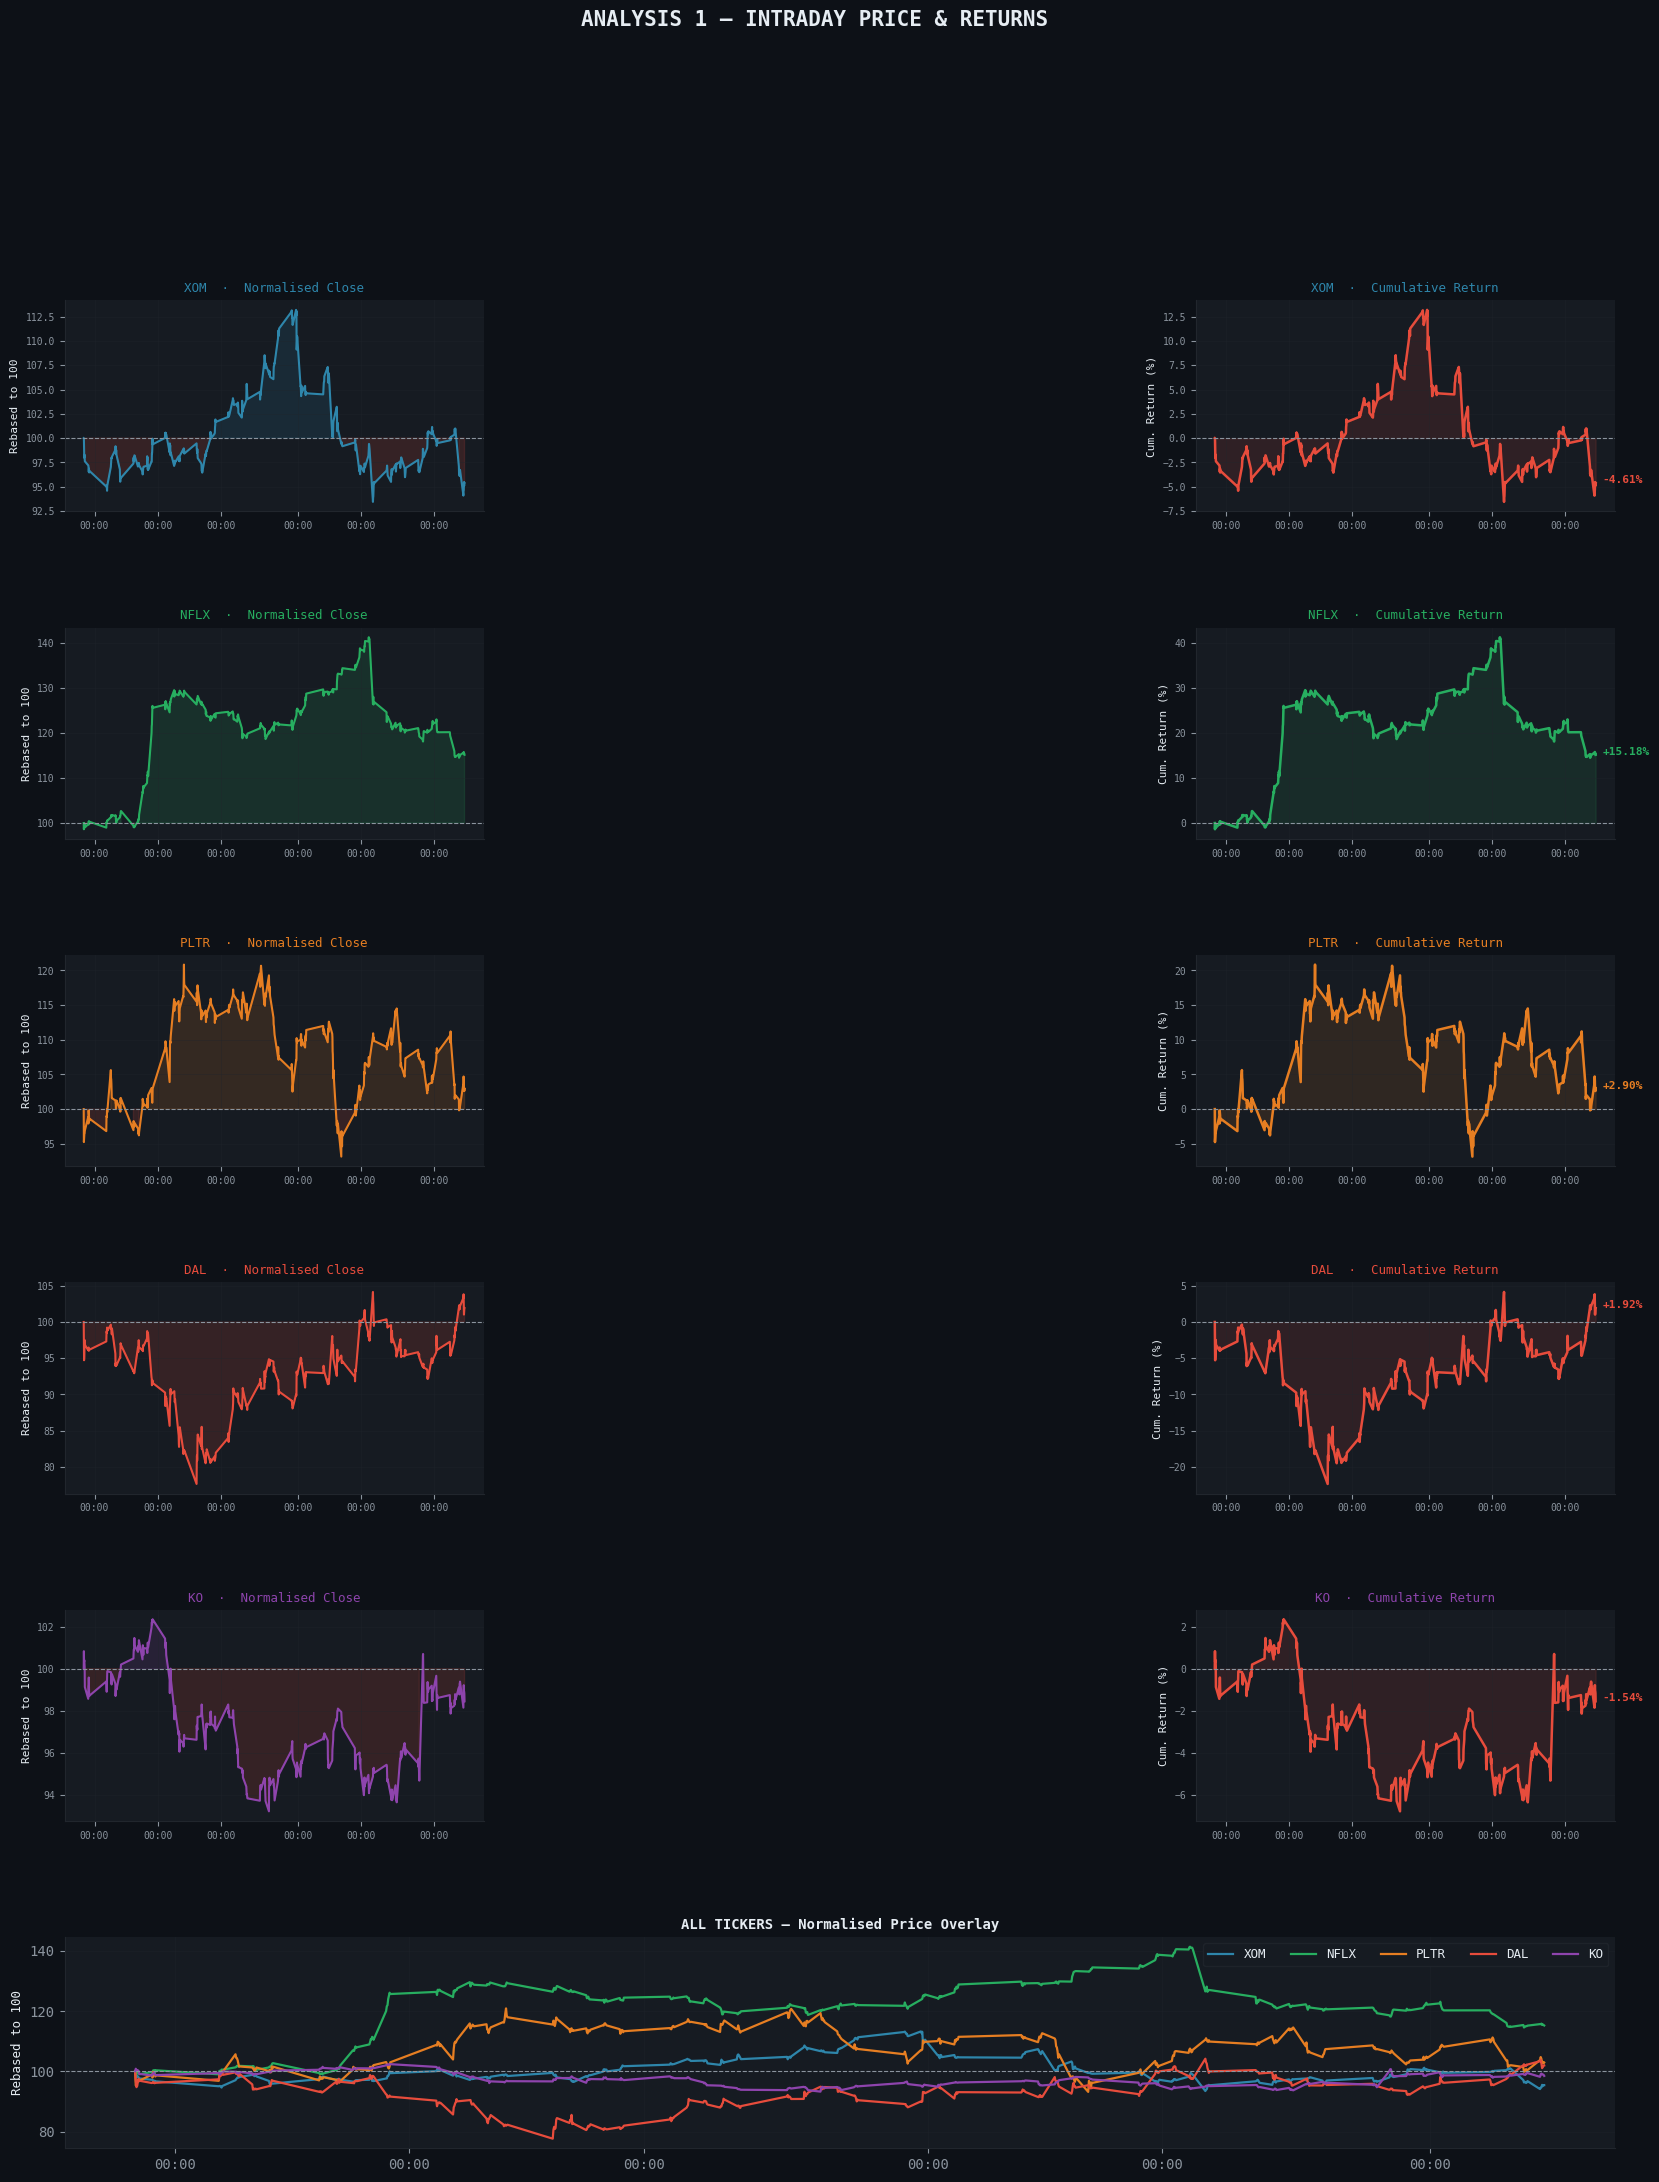

In [3]:
clean_data, audits, clean_reports, anomaly_data = run_pipeline(period="59d")
results = run_analysis(clean_data, output_dir='/content')

from IPython.display import Image, display

display(Image('/content/analysis_1_price_returns.png'))
display(Image('/content/analysis_2_volatility.png'))
display(Image('/content/analysis_3_vwap_liquidity.png'))
display(Image('/content/analysis_4_correlation.png'))

### Phase 5 – Feature Engineering


In [ ]:
# ==========================================
# Phase 5 – Feature Engineering
# ==========================================

print("Starting Phase 5: Feature Engineering...")

for ticker in clean_data:
    df = clean_data[ticker]
    
    # 1. Moving Averages (MA7 and MA30)
    df['MA7'] = df['Close'].rolling(window=7).mean()
    df['MA30'] = df['Close'].rolling(window=30).mean()
    
    # 2. Rolling Volatility (7-day std of daily returns)
    df['Volatility'] = df['returns'].rolling(window=7).std()
    
    # 3. RSI (14-period Relative Strength Index) - From Scratch
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0))
    loss = (-delta.where(delta < 0, 0))
    
    # Using Exponential Moving Average (Wilder's Smoothing approach: alpha = 1/period)
    avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))
    
    # 4. Bollinger Bands (20-day MA ± 2 standard deviations)
    df['BB_Middle'] = df['Close'].rolling(window=20).mean()
    df['BB_Std'] = df['Close'].rolling(window=20).std()
    df['BB_Upper'] = df['BB_Middle'] + (df['BB_Std'] * 2)
    df['BB_Lower'] = df['BB_Middle'] - (df['BB_Std'] * 2)
    
    # 5. Drop NaN rows created by rolling windows
    df.dropna(inplace=True)
    
    # Update the dictionary with the enriched DataFrame
    clean_data[ticker] = df

print("Feature Engineering complete for all tickers.")

# Print sample for one ticker (e.g., PLTR)
sample_ticker = 'PLTR'
print(f"\n--- Sample Enriched Data for {sample_ticker} ---")
display(clean_data[sample_ticker].tail())


### Phase 7 – Machine Learning Modeling


In [ ]:
# ==========================================
# Phase 7 – Machine Learning Modeling
# ==========================================
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set plot style to dark background
plt.style.use('dark_background')

# List to store results for the summary table
results_list = []

print("Starting Phase 7: Machine Learning Modeling...")

for ticker, df in clean_data.items():
    # 1. Prepare Target (y) and Features (X)
    # Target is next day's Close price
    df['Target'] = df['Close'].shift(-1)
    
    # Features list as requested
    feature_cols = ['Open', 'High', 'Low', 'Volume', 'MA7', 'MA30', 'returns', 'Volatility', 'RSI']
    
    # Create copy to avoid SettingWithCopy warnings and drop the last row (where Target is NaN)
    model_df = df.dropna(subset=['Target']).copy()
    
    X = model_df[feature_cols]
    y = model_df['Target']
    
    # 2. Split Data (80% Train, 20% Test) - NO Shuffle for Time Series
    split_idx = int(len(model_df) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    # 3. Train Models
    # Model A: Linear Regression
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    lr_preds = lr_model.predict(X_test)
    
    # Model B: Random Forest Regressor
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    rf_preds = rf_model.predict(X_test)
    
    # 4. Evaluate Models
    models_to_eval = [('Linear Regression', lr_preds), ('Random Forest', rf_preds)]
    
    for name, preds in models_to_eval:
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)
        
        results_list.append({
            'Ticker': ticker,
            'Model': name,
            'MAE': round(mae, 4),
            'RMSE': round(rmse, 4),
            'R²': round(r2, 4)
        })
        
    # 5. Plot Actual vs Predicted
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'{ticker}: Actual vs Predicted Prices', fontsize=16, color='cyan')
    
    # Linear Regression Plot
    ax1.plot(y_test.values, label='Actual', color='white', alpha=0.6)
    ax1.plot(lr_preds, label='LR Predicted', color='yellow', linestyle='--')
    ax1.set_title('Linear Regression')
    ax1.legend()
    ax1.set_ylabel('Price')
    ax1.grid(alpha=0.2)
    
    # Random Forest Plot
    ax2.plot(y_test.values, label='Actual', color='white', alpha=0.6)
    ax2.plot(rf_preds, label='RF Predicted', color='lime', linestyle='--')
    ax2.set_title('Random Forest')
    ax2.legend()
    ax2.set_ylabel('Price')
    ax2.grid(alpha=0.2)
    
    plt.tight_layout()
    plt.show()

# 6. Print Summary Table
summary_df = pd.DataFrame(results_list)
print("\n" + "="*50)
print("             MODEL PERFORMANCE SUMMARY")
print("="*50)
display(summary_df.sort_values(by=['Ticker', 'R²'], ascending=[True, False]))
